# N-BEATS - deep learning model 

In this second notebook, intended to be read after the DataLoading notebook in this same folder,  we implement a state of the art, deep learning model for time series forecasting. It demonstrates model setup, training, and the integration of exogenous variables like GDP for varying forecast horizons. Performance metrics and visualizations assess accuracy and relevance.

## Prerrequisites

This notebook has been written for an audience already familiar with TIP. For users completely new to the platform, we recommend to follow the [TIP basic course](https://e-courses.epo.org/enrol/index.php?id=416) before reading this analysis.

## Disclaimer

This notebook is published as a showcase of the capabilities of TIP as a data processing environment. It is not intended to derive any statistical conclusion other than the presentation of the retrieved data. The EPO is not expressing any opinion extrapolated from the analysis.

## What is N-BEATS

N-BEATS is a deep neural architecture based on backward and forward links and a stack of fully-connected layers. The architecture has some desirable properties, among which the one of being applicable without modification to a wide array of target domains. For the readers interested in the technical details, please refer to *B. Oreshkin, D. Carpov, N. Chapados, Y. Bengio, N-beats: Neural basis expansion analysis for interpretable time series forecasting. arxiv 2019, arXiv preprint arXiv:1905.10437 (2019).*.

Here the Darts [documentation](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.nbeats.html) for the code.

## Installing the `darts` library

Before importing the libraries needed for this notebook, we have to install one external library, named `darts`, that is not available by default. In TIP, you can install python libraries directly within the notebook using commands like `pip install`. However, it is important to note that any libraries installed during your session will not persist once the session is closed. This may take a while.

In [1]:
pip install darts pytorch-lightning --quiet

Note: you may need to restart the kernel to use updated packages.


The `--quiet` command at the end avoids the displaying of the long list of packages downloaded and installed.

Let's start by importing all the classes and libraries needed.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries, concatenate
from darts.utils.callbacks import TFMProgressBar
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, r2_score, rmse
from darts import concatenate

import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


## Defining two functions

In the following, we define two functions. The first one, namely `generate_torch_kwargs` generates progress bars, i.e. a visualisation of the percentage of training performed in real time. The second function, `display_forecast`, automatically plot the results of the model, as the name suggest.

We do not want to spend time explaining what a function is and how it works, and not even to give many details on the two functions defined below. It is enough to know that a function defines a series of operations (sometimes applied to the parameters in input). These operations are performed every time that the function is called in the code.

In [3]:
def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "accelerator": "cpu",
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }

In [4]:
def display_forecast(pred_series, ts_transformed, forecast_type, start_date=None):
    plt.figure(figsize=(8, 5))
    if start_date:
        ts_transformed = ts_transformed.drop_before(start_date)
    ts_transformed.univariate_component(0).plot(label="actual")
    pred_series.plot(label=("historic " + forecast_type + " forecasts"))
    plt.title(
        "R2: {}".format(r2_score(ts_transformed.univariate_component(0), pred_series))
    )
    plt.legend()

## PATSTAT data

We load the data retrieved from PATSTAT and split it in training set, test set, and validation set. Indeed, for this model we also use a validation set. To keep it simple, this set is used as a test set but in the training phase: the model generates a preliminary forecast of the same size of the validation set, based on the data in the training set. This way, the model can correct itself through the several rounds of training.

In [5]:
import os

home = os.environ["HOME"]

ts = pd.read_csv(f'{home}/unique_ts.csv')
# Last 12 observations in the test set
train = ts[:-12]
test = ts[-12:]
# Last 24 observations of the training set go to the validation set
validation = train[-24:]
# Re-define the training set
train = train[:-24]

# Convert the dataframes to TimeSeries objects
train = TimeSeries.from_dataframe(train, time_col='year_month', value_cols='Number of filings')
test = TimeSeries.from_dataframe(test, time_col='year_month', value_cols='Number of filings')
validation = TimeSeries.from_dataframe(validation, time_col='year_month', value_cols='Number of filings')
series = TimeSeries.from_dataframe(ts, time_col='year_month', value_cols='Number of filings')

# Create a Scaler object
scaler = Scaler()

# Scale the data in the range (0,1)
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(validation)
series_scaled = scaler.transform(series)

Now we load the architecture of the model with a generic setting of the hyperparameters. Then, we fit the training data and save the model that provided the best performance.

In [6]:
model_name = "nbeats_run"
# Model setup
model_nbeats = NBEATSModel(
    input_chunk_length=12,
    output_chunk_length=12,
    generic_architecture=True,
    num_stacks=10,
    num_blocks=1,
    num_layers=4,
    layer_widths=512,
    n_epochs=100,
    nr_epochs_val_period=1,
    batch_size=800,
    random_state=42,
    model_name=model_name,
    save_checkpoints=True,
    force_reset=True,
    **generate_torch_kwargs(),
    work_dir=home,
)

# Fitting
model_nbeats.fit(train_scaled, val_series=val_scaled)

# Store the best model
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=model_name, best=True, work_dir=home, weights_only=False)

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  8.0 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 8.0 M                                                                                            
Non-trainable params: 2.6 K                                                                                        
Total params: 8.0 M                                                                                                
Total estimated model params size (MB): 63                                                                         
Modules in train mode: 136                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: 0it [00:00, ?it/s]

Now we compute the one year forecast by using the `historical_forecasts` method, instead of the usual `predict`. This method repeatedly builds a training set: either expanding from the beginning of series or moving with a fixed length. It trains the model on the training set, emits a forecast of length equal to `forecast_horizon`, and then moves the end of the training set forward by `stride` time steps.

In [7]:
pred_series = model_nbeats.historical_forecasts(
    series_scaled,
    start=test.start_time(),
    forecast_horizon=12,
    stride=7,
    last_points_only=False,
    retrain=False,
    verbose=True,
)

pred_series = concatenate(pred_series)

inverted_series = scaler.inverse_transform(pred_series)
# Round the elements to the nearest integer
rounded_inverted_series = np.round(inverted_series.values()).astype(int)
# Convert it back to TimeSeries object
inverted_series = TimeSeries.from_times_and_values(inverted_series.time_index, rounded_inverted_series)

Generating TimeSeries:   0%|          | 0/1 [00:00<?, ?it/s]

Now we plot the results by using the function defined at the beginning of this notebook.

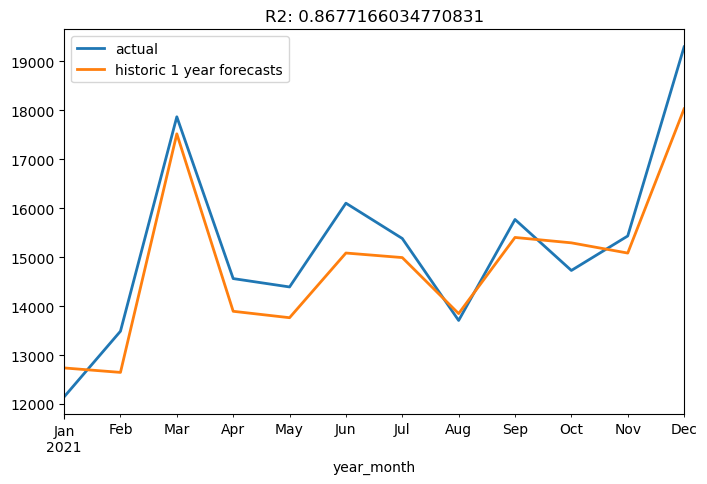

In [8]:
display_forecast(
    inverted_series,
    series,
    "1 year",
    start_date=validation.end_time(),
)

Now we can get the numerical errors.

In [9]:
# evaluate forecasts
RMSE = rmse(test, inverted_series)
MAPE = mape(test, inverted_series)
print('Test RMSE: %.3f' % RMSE)
print('Test MAPE: %.3f' % MAPE)

Test RMSE: 671.046
Test MAPE: 3.905


## EP full-text data, longer time horizon

In this section, we repeat the same operations but on the data retrieved from EP full-text data, hence up to the end of 2022. As before, we use a validation set of two years.

In [10]:
ts = pd.read_csv(f'{home}/epfulltext_unique_ts.csv')
train = ts[:-24]
validation = ts[-24:]

# Convert to TimeSeries objects
train = TimeSeries.from_dataframe(train, time_col='year_month', value_cols='Number_of_filings')
validation = TimeSeries.from_dataframe(validation, time_col='year_month', value_cols='Number_of_filings')
series = TimeSeries.from_dataframe(ts, time_col='year_month', value_cols='Number_of_filings')

# Create a Scaler object
scaler = Scaler()

# Scale the data in the range (0,1)
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(validation)
series_scaled = scaler.transform(series)

We build the model and fit the training data.

In [11]:
model_name = "nbeats_on_epab"
model_nbeats = NBEATSModel(
    input_chunk_length=12,
    output_chunk_length=12,
    generic_architecture=True,
    num_stacks=10,
    num_blocks=1,
    num_layers=4,
    layer_widths=512,
    n_epochs=100,
    nr_epochs_val_period=1,
    batch_size=800,
    random_state=42,
    model_name=model_name,
    save_checkpoints=True,
    force_reset=True,
    **generate_torch_kwargs(),
    work_dir=home,
)

model_nbeats.fit(train_scaled, val_series=val_scaled)

model_nbeats = NBEATSModel.load_from_checkpoint(model_name=model_name, best=True, work_dir=home, weights_only=False)

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  8.0 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 8.0 M                                                                                            
Non-trainable params: 2.6 K                                                                                        
Total params: 8.0 M                                                                                                
Total estimated model params size (MB): 63                                                                         
Modules in train mode: 136                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: 0it [00:00, ?it/s]

In this case, since we are making predictions without a test set of ground values, the `predict` function is more adequate. Then, we reverse the scaling on the results. This time, the forecast_horizon is set to 36 (months).

In [12]:
# Define the forecast horizon
forecast_horizon = 36

pred_series = model_nbeats.predict(
    n=forecast_horizon,  
    series=series_scaled  
)

pred_series = concatenate(pred_series)

inverted_series = scaler.inverse_transform(pred_series)
# Round the elements to the nearest integer
rounded_inverted_series = np.round(inverted_series.values()).astype(int)
# Convert it back to TimeSeries object
inverted_series = TimeSeries.from_times_and_values(inverted_series.time_index, rounded_inverted_series)

Lastly, we plot the observations relative to the years ranging from 2020 to 2022 followed by the 3 years predictions. Let's see another way of plotting the resulting forecast.

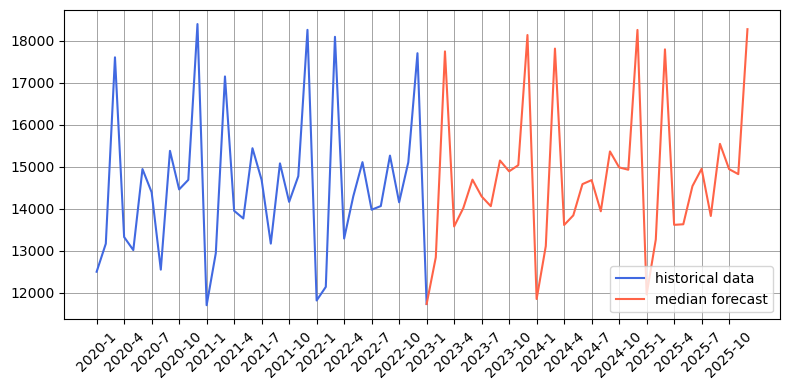

In [13]:
recent_history = ts['Number_of_filings'][-36:]
recent_history_index = ts['year_month'][-36:]

future_index = []
for year in range(2023, 2026):
    for month in range(1, 13):
        future_index.append(f"{year}-{month}")

future_index = pd.Series(future_index)

forecast_vals = inverted_series.univariate_values()

plt.figure(figsize=(8, 4))

plt.plot(
    pd.concat(
        [recent_history_index, pd.Series(future_index.iloc[0])]
    ),
    pd.concat(
        [recent_history, pd.Series([forecast_vals[0]])],
        ignore_index=True
    ),
    color="royalblue",
    label="historical data"
)

plt.plot(
    future_index,
    forecast_vals,
    color="tomato",
    label="median forecast"
)

index = pd.concat([recent_history_index, future_index], ignore_index=True)
plt.xticks(
    ticks=np.arange(0, len(index), 3),
    labels=index[::3],
    rotation=45
)

plt.legend()
plt.grid(color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


The forecast shows continuity with respect to the historical values, and this usually is a sign of reliable projection.

## With covariates

As last exercise in this notebook, we include a covariate in the model, that is the GDP of the applicants. Therefore, we retrieve the data from the CSV file where we stored (in a previous notebook) the yearling number of filings and the GDP of the applicants. In particular, we considered the country (or a specific area in the case of EPO members) of the applicants. Thus, we have 5 different time series, both for filings volume and GDP, for 5 different areas: EPO members, USA, China, Japan, and South Korea.

As first step, we load the data from the CSV file and convert it to a dataframe.

In [14]:
ts = pd.read_csv(f'{home}/filings_with_ex_var.csv')

The set up of the model architecture together with the generation of the predictions is done similarly to what done so far. The difference here is that we have to make predictions for each country. Therefore, we use a for-loop iterating over the list of countries in the dataframe (using the `unique()` method to have the list without duplicates). Before this, we create an empty list where to append the forecasts at the end of each round of the for-loop. The splitting of the dataframe in training and validation sets, and the scaling of the values, are done in the loop too. Here we take 5 years (5 points of the time series) for the validation set.

In [15]:
# Define the forecasts list, initialised as an empty list
forecasts = []

# for-loop over the list of countries
for country in ts['Code'].unique():
    country_ts = ts[ts['Code'] == country]  # Reduce the dataframe to the rows having the current country under the 'Code' attribute
    country_train = country_ts[:-5]
    country_val = country_ts[-5:]
    # Convert to TimeSeries objects
    train = TimeSeries.from_dataframe(country_train, time_col='Year', value_cols=['Number_of_filings', 'ny_gdp_mktp_pp_kd'])
    validation = TimeSeries.from_dataframe(country_val, time_col='Year', value_cols=['Number_of_filings', 'ny_gdp_mktp_pp_kd'])
    series = TimeSeries.from_dataframe(country_ts, time_col='Year', value_cols=['Number_of_filings', 'ny_gdp_mktp_pp_kd'])

    # Define the Scaler object
    scaler = Scaler()

    # Perform the scaling
    train_scaled = scaler.fit_transform(train)
    val_scaled = scaler.transform(validation)
    series_scaled = scaler.transform(series)

    # Initialise the model
    model_name = "nbeats_with_covariates"
    model_nbeats = NBEATSModel(
        input_chunk_length=3,
        output_chunk_length=2,
        generic_architecture=True,
        num_stacks=10,
        num_blocks=1,
        num_layers=4,
        layer_widths=512,
        n_epochs=100,
        nr_epochs_val_period=1,
        batch_size=800,
        random_state=42,
        model_name=model_name,
        save_checkpoints=True,
        force_reset=True,
        **generate_torch_kwargs(),
        work_dir=home,
    )

    # Fit the traning data
    model_nbeats.fit(train_scaled, val_series=val_scaled)

    # Select the best model
    model_nbeats = NBEATSModel.load_from_checkpoint(model_name=model_name, best=True, weights_only=False, work_dir=home)

    # Define the forecast horizon
    forecast_horizon=5

    # Generate the predictions
    pred_series = model_nbeats.predict(
        n=forecast_horizon,
        series=series_scaled
    )
    
    pred_series = concatenate(pred_series)

    # Reverse the scaling on the predictions
    inverted_series = scaler.inverse_transform(pred_series)
    # Round the elements to the nearest integer
    rounded_inverted_series = np.round(inverted_series['Number_of_filings'].values()).astype(int)
    # Convert it back to TimeSeries object
    filings_inverted_series = TimeSeries.from_times_and_values(inverted_series.time_index, rounded_inverted_series)

    # Append the forecast to the forecasts list
    forecasts.append(filings_inverted_series)

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  8.0 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 8.0 M                                                                                            
Non-trainable params: 2.6 K                                                                                        
Total params: 8.0 M                                                                                                
Total estimated model params size (MB): 63                                                                         
Modules in train mode: 136                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: 0it [00:00, ?it/s]

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  8.0 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 8.0 M                                                                                            
Non-trainable params: 2.6 K                                                                                        
Total params: 8.0 M                                                                                                
Total estimated model params size (MB): 63                                                                         
Modules in train mode: 136                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Trainable params: 8.0 M                                                                                            
Non-trainable params: 2.6 K                                                                                        
Total params: 8.0 M                                                                                                
Total estimated model params size (MB): 63                                                                         
Modules in train mode: 136                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: 0it [00:00, ?it/s]

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  8.0 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 8.0 M                                                                                            
Non-trainable params: 2.6 K                                                                                        
Total params: 8.0 M                                                                                                
Total estimated model params size (MB): 63                                                                         
Modules in train mode: 136                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: 0it [00:00, ?it/s]

Also for the plots, we go through a for-loop iterating over the countries and display the forecasts for each of them.

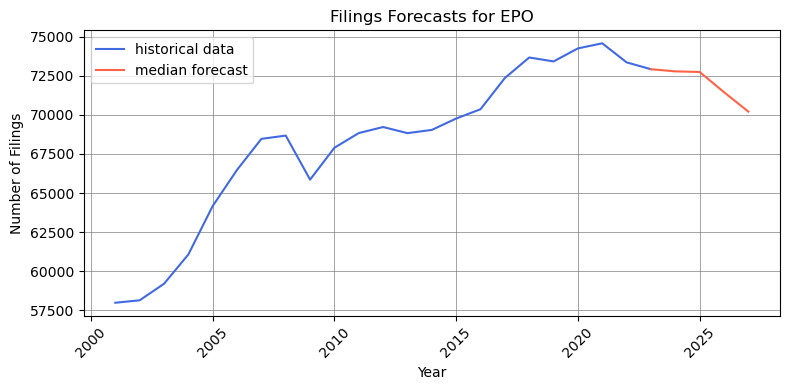

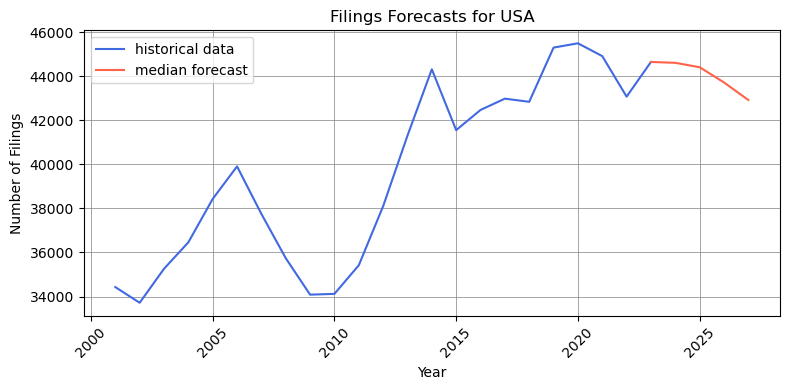

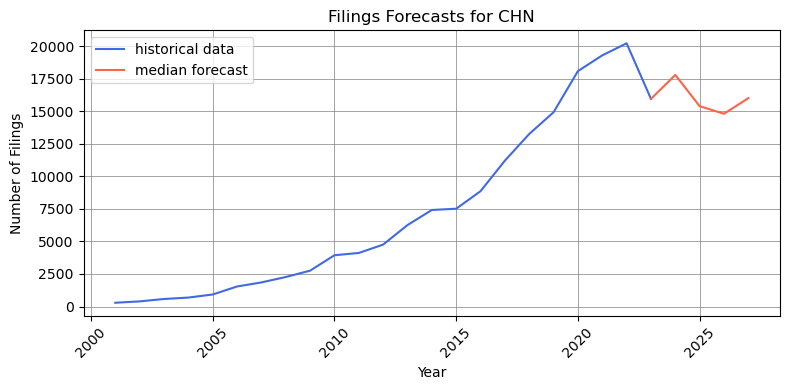

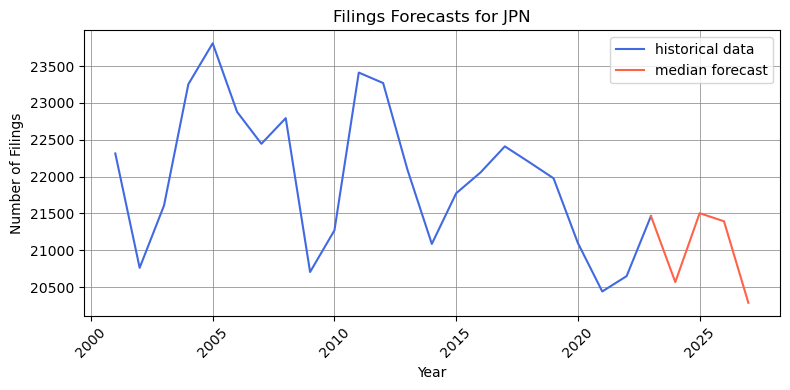

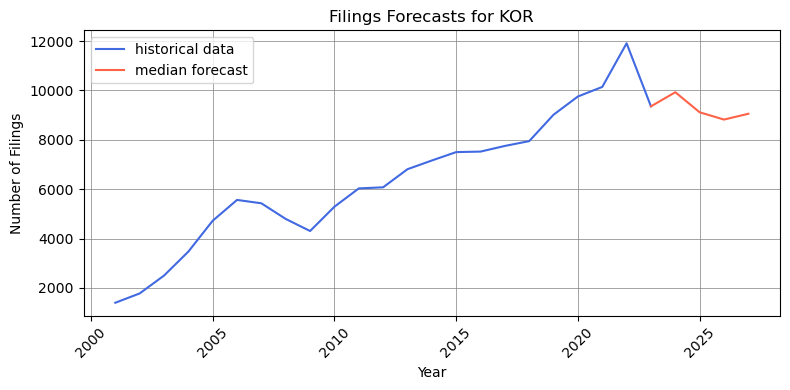

In [16]:
# Assemble the time index of future years
future_index = []
for year in range(2023, 2028):
    future_index.append(year)

future_index = pd.Series(future_index)

# Iterate over the countries
for i, country in enumerate(ts['Code'].unique()):
    country_data = ts[ts['Code'] == country]

    recent_history = country_data['Number_of_filings'][-22:]
    recent_history_index = country_data['Year'][-22:]

    forecast = forecasts[i]
    forecast_vals = forecast.univariate_values()

    plt.figure(figsize=(8, 4))

    # Historical data + connection point
    plt.plot(
        pd.concat([recent_history_index, pd.Series(future_index.iloc[0])]),
        pd.concat([recent_history, pd.Series([forecast_vals[0]])], ignore_index=True),
        color="royalblue",
        label="historical data"
    )

    # Forecast
    plt.plot(
        future_index,
        forecast_vals,
        color="tomato",
        label="median forecast"
    )

    # Plot formatting
    plt.xticks(rotation=45)
    plt.xlabel('Year')
    plt.ylabel('Number of Filings')
    plt.title(f'Filings Forecasts for {country}')
    plt.legend()
    plt.grid(color='gray', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()


In this case, a tuning phase would be needed, since the predicted curves are not always in line with the historical values.